In [25]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [26]:
import torch.nn as nn

import torchvision.models as models

model = models.resnet18(weights='IMAGENET1K_V1')

model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

model.maxpool = nn.Identity()

model.fc = nn.Linear(model.fc.in_features, 1)

mdel = model


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        
        logits  = logits.float()
        targets = targets.float()

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt = targets * probs + (1 - targets) * (1 - probs)
        focal_weight = self.alpha * (1 - pt).pow(self.gamma)
        return (focal_weight * bce).mean()

In [28]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset


class LensDataset(Dataset):
    def __init__(self, lens_dir, nonlens_dir, transform=None):
        self.transform = transform
        lens_files = [(os.path.join(lens_dir, f), 1)
                      for f in os.listdir(lens_dir) if f.endswith('.npy')]
        nonlens_files = [(os.path.join(nonlens_dir, f), 0)
                         for f in os.listdir(nonlens_dir) if f.endswith('.npy')]
        self.data = lens_files + nonlens_files

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        img = np.load(path).astype(np.float32)

        # Clip BEFORE normalizing
        img = np.clip(img, np.percentile(img, 1), np.percentile(img, 99))

        for c in range(img.shape[0]):
            mn, mx = img[c].min(), img[c].max()
            if mx > mn:
                img[c] = (img[c] - mn) / (mx - mn)

        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)


In [29]:
from torchvision import transforms
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, WeightedRandomSampler
import os


def save_checkpoint(state, filename="classification_lensing_best.pth.tar"):
    print("=> Saving checkpoint")
    torch.save(state, filename)


def load_checkpoint(checkpoint_file, model, optimizer=None):
    print("=> Loading checkpoint...")
    checkpoint = torch.load(checkpoint_file, map_location="cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(checkpoint["state_dict"])
    if optimizer and "optimizer" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer"])
    print("Checkpoint loaded successfully!")

def get_loaders(data_dir, train_transform, val_transform, batch_size, num_workers, pin_memory):

    cache_path = os.path.join("/kaggle/working/", "dataset_stats.npz")

    if os.path.exists(cache_path):
        cache = np.load(cache_path)
        mean, std = cache["mean"].tolist(), cache["std"].tolist()
        print(f"Loaded cached stats - Mean: {mean}, Std: {std}")
    else:
        mean, std = compute_dataset_stats(
            os.path.join(data_dir, "train_lenses"),
            os.path.join(data_dir, "train_nonlenses")
        )
        np.savez(cache_path, mean=np.array(mean), std=np.array(std))

    train_transform.transforms.append(transforms.Normalize(mean, std))
    val_transform.transforms.append(transforms.Normalize(mean, std))

    train_dataset = LensDataset(os.path.join(data_dir, "train_lenses"),os.path.join(data_dir, "train_nonlenses"), transform=train_transform)

    test_dataset = LensDataset(os.path.join(data_dir, "test_lenses"),os.path.join(data_dir, "test_nonlenses"), transform=val_transform)

    labels = [s[1] for s in train_dataset.data]
    class_counts = [labels.count(0), labels.count(1)]
    weights = [1.0 / class_counts[l] for l in labels]
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


    train_loader = DataLoader(train_dataset, batch_size=batch_size,sampler=sampler,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader   = DataLoader(test_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    



    print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")


    return train_loader, test_loader, mean, std

def compute_dataset_stats(lens_dir, nonlens_dir):
    all_files = (
        [os.path.join(lens_dir, f) for f in os.listdir(lens_dir) if f.endswith('.npy')] +
        [os.path.join(nonlens_dir, f) for f in os.listdir(nonlens_dir) if f.endswith('.npy')]
    )
    channel_sum  = np.zeros(3)
    channel_sum2 = np.zeros(3)
    n = 0
    for f in all_files:
        img = np.load(f).astype(np.float32)
        for c in range(3):
            mn, mx = img[c].min(), img[c].max()
            if mx > mn:
                img[c] = (img[c] - mn) / (mx - mn)
        channel_sum  += img.mean(axis=(1,2))
        channel_sum2 += (img**2).mean(axis=(1,2))
        n += 1
    mean = channel_sum / n
    std  = np.sqrt(channel_sum2/n - mean**2)
    print(f"Mean: {mean}, Std: {std}")
    return mean.tolist(), std.tolist()

def evaluate_roc_auc(loader, model, device="cuda", save_plot=True):
    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x      = x.to(device)
            logits = model(x).squeeze(1)          # (B,1) -> (B,)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)

    auc = roc_auc_score(all_labels, all_probs)
    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Lens Finding")
    plt.legend()
    plt.tight_layout()

    if save_plot:
        plt.savefig("roc_curve.png", dpi=150)
        print("ROC curve saved.")

    plt.close()
    print(f"\n=== AUC Score: {auc:.4f} ===")
    model.train()
    return {"binary_auc": auc, "macro_avg": auc}

Using device: cuda
Mean: [0.27463181 0.19138429 0.10525908], Std: [0.17354704 0.15477591 0.11311992]
Train samples: 30405 | Test samples: 19650

Epoch [1/30]


Training: 100%|██████████| 238/238 [01:27<00:00,  2.71it/s, loss=0.00772]

  Avg Train Loss: 0.0135



=== AUC Score: 0.9737 ===
  Macro AUC: 0.9737
=> Saving checkpoint
  Best model saved (AUC = 0.9737)

Epoch [2/30]


Training: 100%|██████████| 238/238 [01:31<00:00,  2.60it/s, loss=0.00588]

...

  Avg Train Loss: 0.0006



=== AUC Score: 0.9910 ===
  Macro AUC: 0.9910

Epoch [30/30]


Training: 100%|██████████| 238/238 [01:31<00:00,  2.60it/s, loss=0.000234]

  Avg Train Loss: 0.0006



=== AUC Score: 0.9909 ===
  Macro AUC: 0.9909

=== Final Evaluation on Validation Set ===
ROC curve saved.

=== AUC Score: 0.9909 ===
Training curves saved to training_curves.png


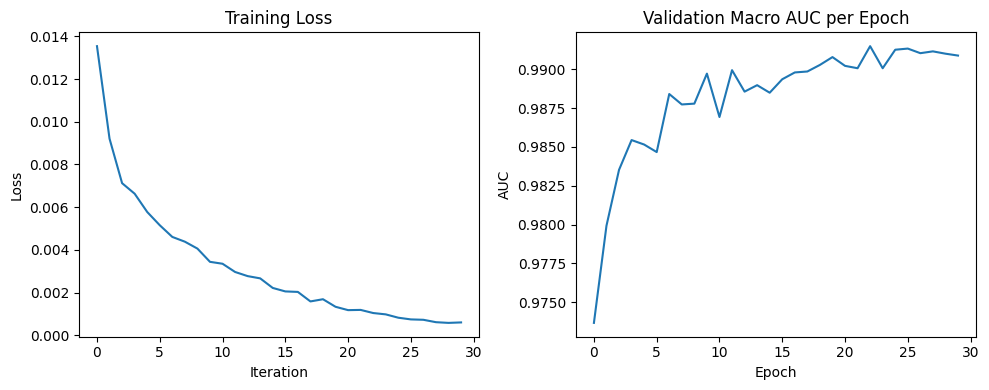

In [30]:
from torchvision import transforms
import torch
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt


LEARNING_RATE   = 1e-4
DEVICE          = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE      = 128
NUM_EPOCHS      = 30
WARMUP_EPOCHS   = 3      
NUM_WORKERS     = 2
PIN_MEMORY      = True
DATA_DIR       = "/kaggle/input/datasets/chaitanyaparate/lens-finding"

train_losses = []
val_auc_history = []

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
])

test_tf = transforms.Compose([

])


def train_fn(loader, model, optimizer, loss_fn):
    model.train()
    loop = tqdm(loader, desc="Training")
    total_loss = 0

    for data, targets in loop:
        data    = data.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        predictions = model(data)
        loss = loss_fn(predictions, targets.unsqueeze(1).float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg = total_loss / len(loader)
    train_losses.append(avg)
    return avg

def main():
    print(f"Using device: {DEVICE}")

    train_loader, test_loader, mean, std = get_loaders(
        DATA_DIR, train_tf, test_tf,
        BATCH_SIZE, NUM_WORKERS, PIN_MEMORY
    )

    model = mdel.to(DEVICE)

    loss_fn   = FocalLoss(alpha=0.25, gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.05)
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS)
    #scaler    = torch.amp.GradScaler()

    best_auc = 0.0

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

        avg_loss = train_fn(train_loader, model, optimizer, loss_fn)
        print(f"  Avg Train Loss: {avg_loss:.4f}")

        auc_scores = evaluate_roc_auc(test_loader, model, device=DEVICE, save_plot=False)
        macro_auc  = auc_scores["macro_avg"]
        val_auc_history.append(macro_auc)

        print(f"  Macro AUC: {macro_auc:.4f}")

        if macro_auc > best_auc:
            best_auc = macro_auc
            save_checkpoint({
                "state_dict": model.state_dict(),
                "optimizer":  optimizer.state_dict(),
                "epoch":      epoch,
                "best_auc":   best_auc,
            })
            print(f"  Best model saved (AUC = {best_auc:.4f})")

        if epoch >= WARMUP_EPOCHS:
            scheduler.step()

    print("\n=== Final Evaluation on Validation Set ===")
    evaluate_roc_auc(test_loader, model, device=DEVICE, save_plot=True)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses)
    plt.title("Training Loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(val_auc_history)
    plt.title("Validation Macro AUC per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    print("Training curves saved to training_curves.png")


if __name__ == "__main__":
    main()
